In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from WBUtiles.WBClean import clean_wb_wide
from WBUtiles.WBSummary import summary_wb, plot_missing_heatmap
from WBUtiles.WBLatex import make_lookup_latex, make_summary_latex

sns.set_theme(
    style="whitegrid",     # clean academic look
    context="paper",       # scales text for papers
    font_scale=1.1
)

# Data Cleaning

In [2]:
gov = pd.read_csv('../data/Zambia_Government Role/gov_role_perform.csv')

In [3]:
gov_clean, gov_lookup = clean_wb_wide(gov, drop_top_rows=0)

In [4]:
print(
    make_lookup_latex(
        gov_lookup,
        caption='World Bank indicators used in Government Role Analysis',
        label='tab:gov_indicator_list'
    )
)

\begin{table}
\caption{World Bank indicators used in Government Role Analysis}
\label{tab:gov_indicator_list}
\begin{tabular}{lp{10cm}}
\toprule
Series Code & Series Name \\
\midrule
FP.CPI.TOTL.ZG & Inflation, consumer prices (annual \%) \\
NY.GDP.DEFL.KD.ZG & Inflation, GDP deflator (annual \%) \\
GC.XPN.TOTL.GD.ZS & Expense (\% of GDP) \\
SH.XPD.GHED.GE.ZS & Domestic general government health expenditure (\% of general government expenditure) \\
SE.XPD.PRIM.ZS & Expenditure on primary education (\% of government expenditure on education) \\
SE.XPD.SECO.ZS & Expenditure on secondary education (\% of government expenditure on education) \\
SE.XPD.TERT.ZS & Expenditure on tertiary education (\% of government expenditure on education) \\
NE.CON.GOVT.ZS & General government final consumption expenditure (\% of GDP) \\
NE.CON.GOVT.KD.ZG & General government final consumption expenditure (annual \% growth) \\
NE.CON.GOVT.KD & General government final consumption expenditure (constant 2015 

# Check data availability by series and year

In [5]:
gov_summary = summary_wb(gov_clean, gov_lookup)
gov_summary

,Series Code,Series Name,missing_pct,n_obs,first_year,last_year
0,FP.CPI.TOTL.ZG,"Inflation, consumer prices (annual %)",40.000000,39,1986.0,2024.0
1,NY.GDP.DEFL.KD.ZG,"Inflation, GDP deflator (annual %)",1.538462,64,1961.0,2024.0
2,GC.XPN.TOTL.GD.ZS,Expense (% of GDP),64.615385,23,1998.0,2021.0
3,SH.XPD.GHED.GE.ZS,Domestic general government health expenditure...,63.076923,24,2000.0,2023.0
4,SE.XPD.PRIM.ZS,Expenditure on primary education (% of governm...,55.384615,29,1970.0,2017.0
5,SE.XPD.SECO.ZS,Expenditure on secondary education (% of gover...,55.384615,29,1970.0,2017.0
6,SE.XPD.TERT.ZS,Expenditure on tertiary education (% of govern...,55.384615,29,1970.0,2017.0
7,NE.CON.GOVT.ZS,General government final consumption expenditu...,76.923077,15,2010.0,2024.0
8,NE.CON.GOVT.KD.ZG,General government final consumption expenditu...,100.000000,0,NaN,NaN
9,NE.CON.GOVT.KD,General government final consumption expenditu...,98.461538,1,2015.0,2015.0


In [6]:
print(
    make_summary_latex(
    gov_summary,
    caption='Data availability of Government Role (Zambia)',
    label='tab:gov_data_availability')
)

\begin{table}
\caption{Data availability of Government Role (Zambia)}
\label{tab:gov_data_availability}
\begin{tabular}{lrrrr}
\toprule
Series Code & Missing (\textbackslash \%) & Obs. & First year & Last year \\
\midrule
FP.CPI.TOTL.ZG & 40.00 & 39 & 1986.00 & 2024.00 \\
NY.GDP.DEFL.KD.ZG & 1.50 & 64 & 1961.00 & 2024.00 \\
GC.XPN.TOTL.GD.ZS & 64.60 & 23 & 1998.00 & 2021.00 \\
SH.XPD.GHED.GE.ZS & 63.10 & 24 & 2000.00 & 2023.00 \\
SE.XPD.PRIM.ZS & 55.40 & 29 & 1970.00 & 2017.00 \\
SE.XPD.SECO.ZS & 55.40 & 29 & 1970.00 & 2017.00 \\
SE.XPD.TERT.ZS & 55.40 & 29 & 1970.00 & 2017.00 \\
NE.CON.GOVT.ZS & 76.90 & 15 & 2010.00 & 2024.00 \\
NE.CON.GOVT.KD.ZG & 100.00 & 0 & NaN & NaN \\
NE.CON.GOVT.KD & 98.50 & 1 & 2015.00 & 2015.00 \\
SE.XPD.TOTL.GB.ZS & 70.80 & 19 & 2000.00 & 2024.00 \\
MS.MIL.XPND.ZS & 67.70 & 21 & 2004.00 & 2024.00 \\
GC.NLD.TOTL.GD.ZS & 64.60 & 23 & 1998.00 & 2021.00 \\
IC.FRM.DURS & 95.40 & 3 & 2007.00 & 2019.00 \\
CC.EST & 61.50 & 25 & 1996.00 & 2023.00 \\
CC.PER.RNK & 61.5

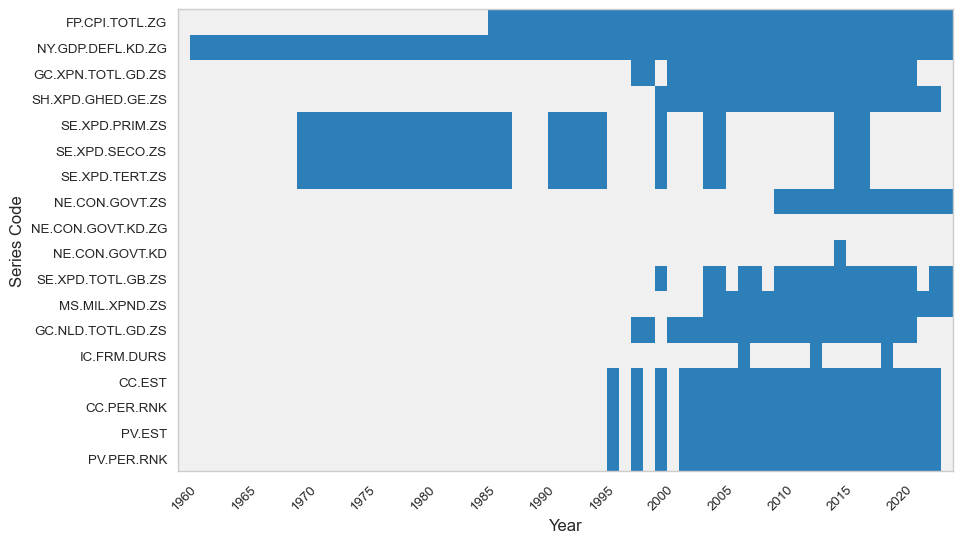

In [7]:
availability, fig, ax = plot_missing_heatmap(
    gov_clean,
    lookup=gov_lookup
)

fig.savefig(
    "../figures/gov_role/data_availability_heatmap.pdf",
    format="pdf",
    bbox_inches="tight"
)

# Data Visualization

In [8]:
gov_lookup

,Series Code,Series Name
0,FP.CPI.TOTL.ZG,"Inflation, consumer prices (annual %)"
1,NY.GDP.DEFL.KD.ZG,"Inflation, GDP deflator (annual %)"
2,GC.XPN.TOTL.GD.ZS,Expense (% of GDP)
3,SH.XPD.GHED.GE.ZS,Domestic general government health expenditure...
4,SE.XPD.PRIM.ZS,Expenditure on primary education (% of governm...
5,SE.XPD.SECO.ZS,Expenditure on secondary education (% of gover...
6,SE.XPD.TERT.ZS,Expenditure on tertiary education (% of govern...
7,NE.CON.GOVT.ZS,General government final consumption expenditu...
8,NE.CON.GOVT.KD.ZG,General government final consumption expenditu...
9,NE.CON.GOVT.KD,General government final consumption expenditu...
